In [64]:
# import mesa_reader to make its classes accessible
import mesa_reader as mr
import matplotlib.pyplot as plt
import numpy as np
import numpy as np
from scipy.interpolate import interp1d

In [65]:
import numpy as np
h_1 = mr.MesaData('/home/alyssa.atkinson/Desktop/AST1410/MESA/prac3/star1/LOGS/history.data')
h_3 = mr.MesaData('/home/alyssa.atkinson/Desktop/AST1410/MESA/prac3/star3/LOGS/history.data')
h_4 = mr.MesaData('/home/alyssa.atkinson/Desktop/AST1410/MESA/prac3/star4/LOGS/history.data')
h_5 = mr.MesaData('/home/alyssa.atkinson/Desktop/AST1410/MESA/prac3/star5/LOGS/history.data')
h_6 = mr.MesaData('/home/alyssa.atkinson/Desktop/AST1410/MESA/prac3/star6/LOGS/history.data')
h_7 = mr.MesaData('/home/alyssa.atkinson/Desktop/AST1410/MESA/prac3/star7/LOGS/history.data')
h_9 = mr.MesaData('/home/alyssa.atkinson/Desktop/AST1410/MESA/prac3/star9/LOGS/history.data')
h_8 = mr.MesaData('/home/alyssa.atkinson/Desktop/AST1410/MESA/prac3/star8/LOGS/history.data')
h_10 = mr.MesaData('/home/alyssa.atkinson/Desktop/AST1410/MESA/prac3/star10/LOGS/history.data')
h_11 = mr.MesaData('/home/alyssa.atkinson/Desktop/AST1410/MESA/prac3/star11/LOGS/history.data')

In [152]:

interp_grid = np.zeros((10, 3, 100000)) 

masses = [0.3, 0.4,  0.5, 1, 2, 5, 10, 11, 12 ,20]
tracks = [ h_8, h_9, h_7, h_5, h_6, h_3, h_4, h_11, h_10 , h_1]
for i, track in enumerate(tracks) :
    age = track.star_age
    teff = track.log_Teff
    lum = track.log_L

    age_dense = np.linspace(age.min(), age.max(), 100000)
    print(age.max())
    teff_interp = interp1d(age, teff, kind='quadratic')
    lum_interp = interp1d(age, lum, kind='quadratic')
    teff_dense = teff_interp(age_dense)
    lum_dense = lum_interp(age_dense)

    interp_grid[i,0,: ] = age_dense # age 
    interp_grid[i,1,: ] = teff_dense # teff
    interp_grid[i,2,: ] = lum_dense # lum
    
    

10000000000.0
10000000000.0
10000000000.0
10000000000.0
1048674408.1311421
104861593.12638678
23086248.038114697
39548324.95252364
14591624.602240533
8483555.529603386


starting new age
starting new age
starting new age
starting new age
starting new age
starting new age
starting new age
starting new age


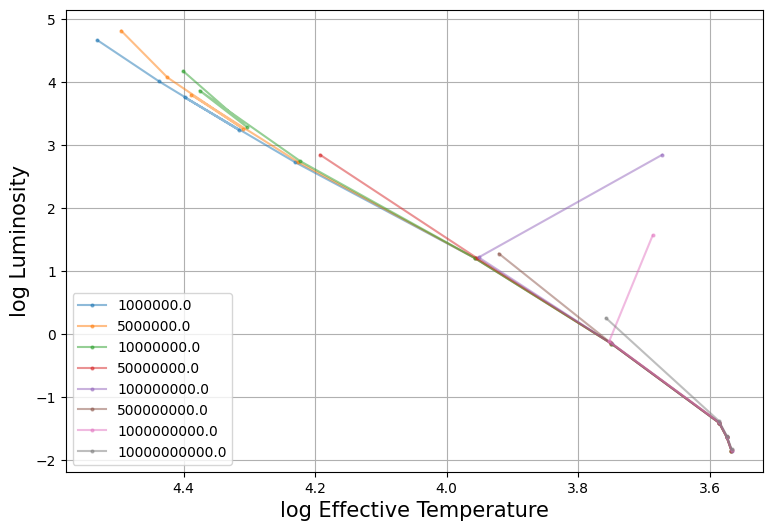

In [142]:

masses = [0.3, 0.4,  0.5, 1, 2, 5, 10,11, 12 , 20]

turnoff_mass = []

# choose isochrone ages (years)
ages =[1e6, 5e6,1e7 ,5e7 , 1e8, 5e8, 1e9, 1e10]
fig, ax = plt.subplots(figsize=(9,6))

for age in ages:
    print('starting new age')
    teff = []
    lum = []
    masses_ran = []
   
    for i in range(0, 10):
        
        

        ind = np.argmin(np.abs(interp_grid[i, 0, :] - age))
        diff = interp_grid[i, 0, ind] -age

        if np.abs(diff)<1e5:
            teff.append(interp_grid[i, 1, ind])
            lum.append(interp_grid[i, 2, ind])
            masses_ran.append(masses[i])

    turnoff_mass.append(masses_ran[-1])
        


    #ax.scatter(teff, lum , label= str(age), alpha = 0.5, marker ='o')
    ax.plot(teff, lum , label= str(age), alpha = 0.5, marker ='o', markersize =2)
    


ax.set_xlabel('log Effective Temperature', fontsize=15)
ax.set_ylabel('log Luminosity', fontsize=15)
#ax.set_xlim(3.6, 4.0)
ax.invert_xaxis()



# load tracks
ax.grid()
ax.legend()
plt.show()

In [101]:
# compute age and mass of main sequence turn off
mass = []
age = []
tracks = [ h_8, h_9, h_7, h_5, h_6, h_3, h_4, h_11, h_10 , h_1]
for model in tracks:
    if model is h_5: 
        ind = np.argmax(model.log_Teff)
    else:
        ind = np.argmin(model.log_Teff)
    mass.append(model.star_mass[ind])
    age.append(model.star_age[ind])
        

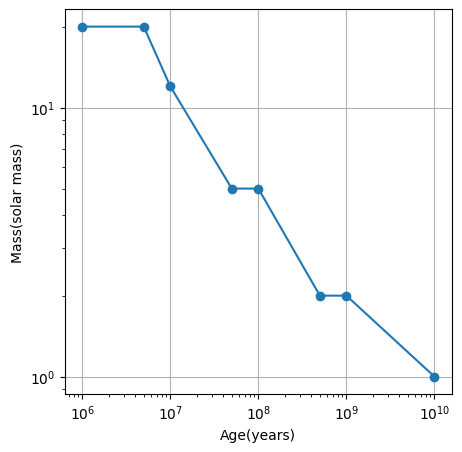

In [151]:
fig, ax = plt.subplots(1, figsize = (5,5))
# load and plot data
ax.plot(ages, turnoff_mass, marker = 'o')
ax.set_xlabel('Age(years)')

ax.set_ylabel('Mass(solar mass)')
ax.set_yscale('log')
ax.set_xscale('log') 
ax.grid()